<a href="https://colab.research.google.com/github/Jashed-20/medical-image-segmentation/blob/main/image_segementation_01.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [43]:
!mkdir -p ~/.kaggle
!cp kaggle.json ~/.kaggle/
!chmod 600 ~/.kaggle/kaggle.json

In [ ]:
!kaggle datasets download -d mateuszbuda/lgg-mri-segmentation

In [ ]:
!unzip lgg-mri-segmentation.zip

In [45]:
import os
import cv2
import matplotlib.pyplot as plt

In [46]:
import os
import cv2
import matplotlib.pyplot as plt

dataset_path = "/content/lgg-mri-segmentation/kaggle_3m"

image_paths = []
mask_paths = []

for patient_folder in os.listdir(dataset_path):

    patient_path = os.path.join(dataset_path, patient_folder)

    if os.path.isdir(patient_path):

        for file in os.listdir(patient_path):

            full_path = os.path.join(patient_path, file)

            if "mask" in file:
                mask_paths.append(full_path)

            elif file.endswith(".tif"):
                image_paths.append(full_path)

image_paths = sorted(image_paths)
mask_paths = sorted(mask_paths)

print("Images:", len(image_paths))
print("Masks:", len(mask_paths))

Images: 3929
Masks: 3929


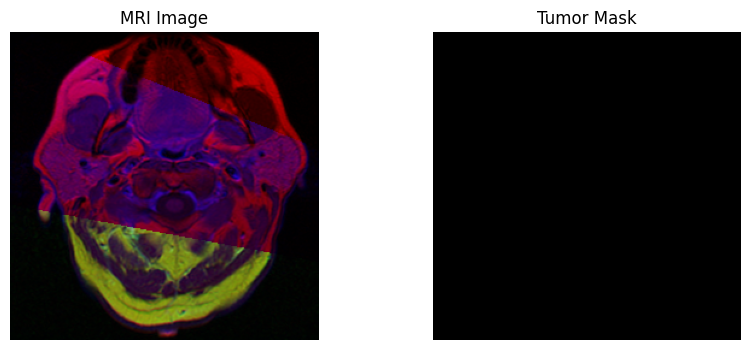

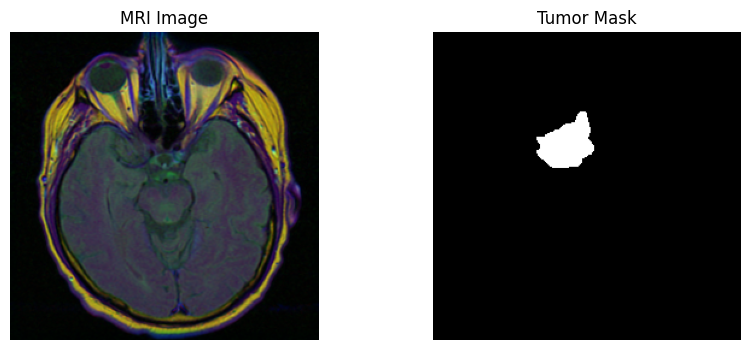

In [47]:
for i in range(2):

    image = cv2.imread(image_paths[i])
    image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

    mask = cv2.imread(mask_paths[i], 0)

    plt.figure(figsize=(10,4))

    plt.subplot(1,2,1)
    plt.imshow(image)
    plt.title("MRI Image")
    plt.axis("off")

    plt.subplot(1,2,2)
    plt.imshow(mask, cmap='gray')
    plt.title("Tumor Mask")
    plt.axis("off")

    plt.show()

In [48]:

IMG_SIZE = 256

def preprocess_image(img_path):
    img = cv2.imread(img_path)
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

    img = cv2.resize(img, (IMG_SIZE, IMG_SIZE), interpolation=cv2.INTER_LINEAR)

    img = img / 255.0
    return img


def preprocess_mask(mask_path):
    mask = cv2.imread(mask_path, 0)

    mask = cv2.resize(mask, (IMG_SIZE, IMG_SIZE), interpolation=cv2.INTER_NEAREST)

    mask = mask / 255.0
    mask = (mask > 0.5).astype("float32")

    return mask


In [49]:
import torch
import torch.nn as nn
import torchvision.models as models

In [50]:
class ResNet50Encoder(nn.Module):
    def __init__(self, pretrained=True):
        super().__init__()

        resnet = models.resnet50(pretrained=pretrained)


        self.conv1 = resnet.conv1
        self.bn1 = resnet.bn1
        self.relu = resnet.relu
        self.maxpool = resnet.maxpool


        self.layer1 = resnet.layer1  # 256 channels
        self.layer2 = resnet.layer2  # 512
        self.layer3 = resnet.layer3  # 1024
        self.layer4 = resnet.layer4  # 2048

    def forward(self, x):
        x1 = self.conv1(x)
        x1 = self.bn1(x1)
        x1 = self.relu(x1)

        x2 = self.maxpool(x1)
        x2 = self.layer1(x2)

        x3 = self.layer2(x2)

        x4 = self.layer3(x3)

        x5 = self.layer4(x4)

        return x1, x2, x3, x4, x5

In [51]:
class DecoderBlock(nn.Module):
    def __init__(self, in_channels, out_channels):
        super().__init__()

        self.up = nn.ConvTranspose2d(in_channels, out_channels, kernel_size=2, stride=2)

        self.conv = nn.Sequential(
            nn.Conv2d(out_channels + out_channels, out_channels, 3, padding=1),
            nn.BatchNorm2d(out_channels),
            nn.ReLU(inplace=True),

            nn.Conv2d(out_channels, out_channels, 3, padding=1),
            nn.BatchNorm2d(out_channels),
            nn.ReLU(inplace=True),
        )

    def forward(self, x, skip):
        x = self.up(x)

        if x.shape != skip.shape:
            x = nn.functional.interpolate(x, size=skip.shape[2:])

        x = torch.cat([x, skip], dim=1)

        x = self.conv(x)

        return x

In [52]:
class ResNet50_UNet(nn.Module):
    def __init__(self, num_classes=1):
        super().__init__()

        self.encoder = ResNet50Encoder(pretrained=True)


        self.dec4 = DecoderBlock(2048, 1024)
        self.dec3 = DecoderBlock(1024, 512)
        self.dec2 = DecoderBlock(512, 256)
        self.dec1 = DecoderBlock(256, 64)


        self.final_up = nn.ConvTranspose2d(64, 32, kernel_size=2, stride=2)

        self.final_conv = nn.Conv2d(32, num_classes, kernel_size=1)

    def forward(self, x):


        x1, x2, x3, x4, x5 = self.encoder(x)


        d4 = self.dec4(x5, x4)
        d3 = self.dec3(d4, x3)
        d2 = self.dec2(d3, x2)
        d1 = self.dec1(d2, x1)

        x = self.final_up(d1)
        x = self.final_conv(x)

        return x

In [53]:
from torch.utils.data import Dataset
import cv2
import torch
import numpy as np

class MRIDataset(Dataset):
    def __init__(self, image_paths, mask_paths, img_size=256):
        self.image_paths = image_paths
        self.mask_paths = mask_paths
        self.img_size = img_size

    def __len__(self):
        return len(self.image_paths)

    def __getitem__(self, idx):

        # Image
        img = cv2.imread(self.image_paths[idx])
        img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
        img = cv2.resize(img, (self.img_size, self.img_size))
        img = img / 255.0

        # Mask
        mask = cv2.imread(self.mask_paths[idx], 0)
        mask = cv2.resize(mask, (self.img_size, self.img_size))
        mask = mask / 255.0
        mask = (mask > 0.5).astype(np.float32)

        # Convert to tensor
        img = torch.tensor(img).permute(2,0,1).float()
        mask = torch.tensor(mask).unsqueeze(0).float()

        return img, mask

In [70]:
from torch.utils.data import DataLoader

dataset = MRIDataset(image_paths, mask_paths)

train_loader = DataLoader(dataset, batch_size=10, shuffle=True)

In [71]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

model = ResNet50_UNet(num_classes=1).to(device)

In [79]:


class DiceLoss(nn.Module):
    def __init__(self):
        super(DiceLoss, self).__init__()

    def forward(self, preds, targets):
        preds = torch.sigmoid(preds)

        smooth = 1e-6
        intersection = (preds * targets).sum()
        dice = (2. * intersection + smooth) / (preds.sum() + targets.sum() + smooth)

        return 1 - dice


bce = nn.BCEWithLogitsLoss()
dice_loss = DiceLoss()

def combined_loss(preds, targets):
    return bce(preds, targets) + dice_loss(preds, targets)

In [80]:
loss = combined_loss(outputs, masks)
import torch.optim as optim

optimizer = optim.Adam(model.parameters(), lr=1e-4)

In [ ]:
epochs = 30

for epoch in range(epochs):
    total_loss = 0

    for i, (images, masks) in enumerate(train_loader):
        images = images.to(device)
        masks = masks.to(device)

        outputs = model(images)
        loss = criterion(outputs, masks)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        total_loss += loss.item()

        if i % 10 == 0:
            print(f"Epoch {epoch+1}, Step {i}, Loss: {loss.item():.4f}")

    print(f"✅ Epoch {epoch+1} completed | Avg Loss: {total_loss/len(train_loader):.4f}")

In [82]:


def visualize(model, dataset, device, index=0):
    model.eval()

    image, mask = dataset[index]
    image_input = image.unsqueeze(0).to(device)

    with torch.no_grad():
        output = model(image_input)
        pred = torch.sigmoid(output)

    image = image.permute(1, 2, 0).cpu().numpy()
    mask = mask.squeeze().cpu().numpy()
    pred = pred.squeeze().cpu().numpy()

    pred_bin = (pred > 0.5).astype(np.float32)

    plt.figure(figsize=(12, 4))

    # MRI Image
    plt.subplot(1, 4, 1)
    plt.imshow(image)
    plt.title("MRI Image")
    plt.axis("off")

    # Ground Truth
    plt.subplot(1, 4, 2)
    plt.imshow(mask, cmap="gray")
    plt.title("Ground Truth")
    plt.axis("off")

    # Prediction
    plt.subplot(1, 4, 3)
    plt.imshow(pred_bin, cmap="gray")
    plt.title("Prediction")
    plt.axis("off")

    # Overlay
    plt.subplot(1, 4, 4)
    plt.imshow(image)
    plt.imshow(pred_bin, cmap="jet", alpha=0.5)
    plt.title("Overlay")
    plt.axis("off")

    plt.show()

In [83]:
def dice_f1_score(pred, mask, threshold=0.5):

    pred = (pred > threshold).astype(np.float32)
    mask = mask.astype(np.float32)

    TP = np.sum((pred == 1) & (mask == 1))
    FP = np.sum((pred == 1) & (mask == 0))
    FN = np.sum((pred == 0) & (mask == 1))

    # Dice Score
    dice = (2 * TP) / (2 * TP + FP + FN + 1e-8)

    # Precision & Recall
    precision = TP / (TP + FP + 1e-8)
    recall = TP / (TP + FN + 1e-8)

    # F1 Score
    f1 = (2 * precision * recall) / (precision + recall + 1e-8)

    return dice, f1

In [84]:
def evaluate(model, dataset, device):

    model.eval()

    dice_scores = []
    f1_scores = []

    for i in range(len(dataset)):

        image, mask = dataset[i]
        image_input = image.unsqueeze(0).to(device)

        with torch.no_grad():
            output = model(image_input)
            pred = torch.sigmoid(output)

        pred = pred.squeeze().cpu().numpy()
        mask = mask.squeeze().cpu().numpy()

        dice, f1 = dice_f1_score(pred, mask)

        dice_scores.append(dice)
        f1_scores.append(f1)

    print("\n===== MODEL PERFORMANCE =====")
    print(f"Dice Score : {np.mean(dice_scores):.4f}")
    print(f"F1 Score   : {np.mean(f1_scores):.4f}")

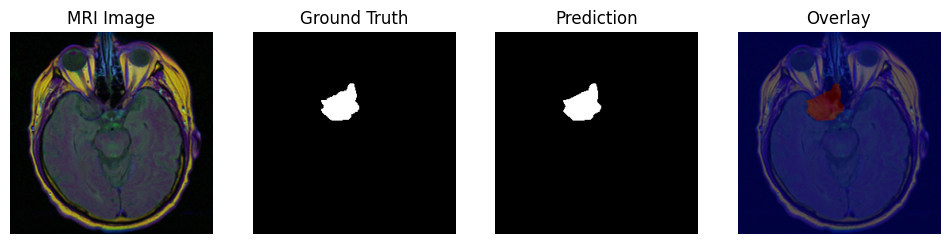

In [85]:
visualize(model, dataset, device, index=1)


In [ ]:
evaluate(model, dataset, device)